# Specialist Model for Extreme Boundary Cases

## Motivation

Our analysis in working_11.ipynb revealed that general-purpose models struggle with extreme boundary cases, even when trained with importance sampling. This raises a natural question: would a model trained **exclusively** on extreme cases outperform general models in these challenging regions?

## The Specialist Approach

We train a GRU model exclusively on extreme boundary cases:
- High autocorrelation: $|\rho| > 0.95$ (near unit root behavior)
- Low noise: $\sigma < 0.05$ (high signal-to-noise ratio)

These regions are challenging because:
1. Near unit roots ($|\rho| \approx 1$) lead to near non-stationarity
2. Low noise makes the time series highly deterministic, reducing information content
3. These cases are rare in uniform sampling, limiting training exposure

## Hypothesis

A specialist model may outperform general models because:
- Dedicated capacity focused on extreme regime dynamics
- No need to compromise between extreme and typical cases
- Direct uniform sampling from target distribution (no importance weighting variance)

We test this hypothesis through comprehensive comparison against general models and Gibbs sampling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import torch
import torch.nn as nn
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060


In [2]:
# Configuration
A = 5.0
T = 64

# Extreme boundary definitions
RHO_THRESHOLD = 0.95  # |rho| > 0.95
SIGMA_THRESHOLD = 0.05  # sigma < 0.05

# Training hyperparameters
N_EPOCHS = 128
N_BATCHES_PER_EPOCH = 128
TRAINING_BATCH_SIZE = 128

# Evaluation: large sample for robust statistics
N_EVAL_POINTS = 20000

## Core Implementation

In [3]:
def sample_extreme_parameters(batch_size, rho_threshold, sigma_threshold, A, device='cpu'):
    """Sample parameters from extreme boundary regions only"""
    rho = torch.empty(batch_size, device=device)
    sigma = torch.empty(batch_size, device=device)
    
    # Sample rho from [-1, -rho_threshold] or [rho_threshold, 1]
    # Randomly choose positive or negative extreme
    sign = torch.randint(0, 2, (batch_size,), device=device) * 2 - 1  # -1 or 1
    rho_extreme = torch.rand(batch_size, device=device) * (1 - rho_threshold) + rho_threshold
    rho = sign * rho_extreme
    
    # Sample sigma from [0, sigma_threshold]
    sigma = torch.rand(batch_size, device=device) * sigma_threshold
    
    return rho, sigma

def simulate_ar1_batch(rho, sigma, T, batch_size, device='cpu'):
    """Vectorized AR(1) simulation with numerical stability"""
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    
    rho_safe = torch.clamp(rho, -0.9999, 0.9999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    
    return x

print("Extreme sampling functions loaded")

Extreme sampling functions loaded


In [4]:
# Gibbs sampler
def truncated_normal(mu, sigma, a=-1, b=1):
    while True:
        sample = np.random.normal(mu, sigma)
        if a <= sample <= b:
            return sample

def truncated_gamma(shape, scale, a=1/A**2):
    while True:
        sample = np.random.gamma(shape, scale)
        if sample >= a:
            return sample

def gibbs(x, n_iter=1000):
    T = len(x) - 1
    Q = np.sum(x[:-1]**2)
    rho_hat = np.sum(x[:-1] * x[1:]) / Q
    const = np.sum(x[1:]**2) - Q * rho_hat**2
    
    S = lambda rho: Q * (rho - rho_hat)**2 + const
               
    samples = np.zeros((n_iter, 2))
    for i in range(n_iter):
        lambda_ = truncated_gamma(T/2, 2/(S(rho_hat) + 1e-6))
        sigma = 1/np.sqrt(lambda_)
        samples[i, 1] = sigma
        samples[i, 0] = truncated_normal(rho_hat, sigma/np.sqrt(Q))

    return samples

print("Gibbs sampler loaded")

Gibbs sampler loaded


In [5]:
class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, output_dim=2, mlp_hidden=64):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.estimator = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    
    def forward(self, x):
        x = x.unsqueeze(-1)
        gru_out, h_n = self.gru(x)
        last_hidden = h_n[-1]
        out = self.estimator(last_hidden)
        out[:, 0] = torch.tanh(out[:, 0])  # rho in [-1, 1]
        out[:, 1] = torch.sigmoid(out[:, 1]) * A  # sigma in [0, A]
        return out

print("Model architecture loaded")

Model architecture loaded


## Visualizing the Extreme Training Distribution

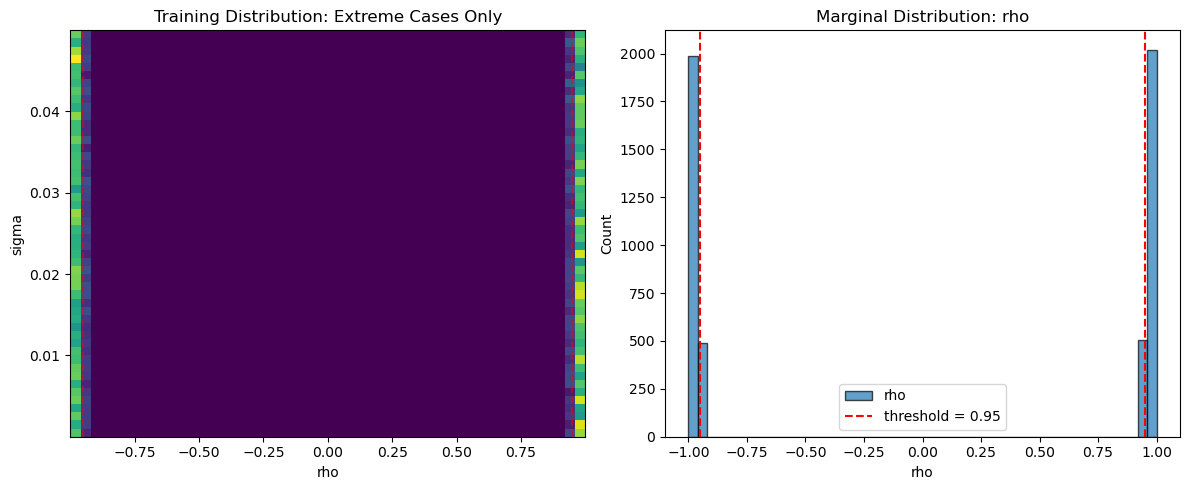

Training regime:
  rho range: [-1.000, 1.000]
  sigma range: [0.000, 0.050]
  Fraction |rho| > 0.95: 1.000
  Fraction sigma < 0.05: 1.000


In [6]:
# Visualize what the specialist model sees during training
n_samples = 5000
rho_viz, sigma_viz = sample_extreme_parameters(n_samples, RHO_THRESHOLD, SIGMA_THRESHOLD, A, device='cpu')
rho_viz = rho_viz.numpy()
sigma_viz = sigma_viz.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2D histogram
axes[0].hist2d(rho_viz, sigma_viz, bins=50, cmap='viridis')
axes[0].set_xlabel('rho')
axes[0].set_ylabel('sigma')
axes[0].set_title('Training Distribution: Extreme Cases Only')
axes[0].axvline(x=RHO_THRESHOLD, color='r', linestyle='--', alpha=0.5)
axes[0].axvline(x=-RHO_THRESHOLD, color='r', linestyle='--', alpha=0.5)
axes[0].axhline(y=SIGMA_THRESHOLD, color='r', linestyle='--', alpha=0.5)

# Marginal distributions
axes[1].hist(rho_viz, bins=50, alpha=0.7, label='rho', edgecolor='black')
axes[1].axvline(x=RHO_THRESHOLD, color='r', linestyle='--', label=f'threshold = {RHO_THRESHOLD}')
axes[1].axvline(x=-RHO_THRESHOLD, color='r', linestyle='--')
axes[1].set_xlabel('rho')
axes[1].set_ylabel('Count')
axes[1].set_title('Marginal Distribution: rho')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Training regime:")
print(f"  rho range: [{rho_viz.min():.3f}, {rho_viz.max():.3f}]")
print(f"  sigma range: [{sigma_viz.min():.3f}, {sigma_viz.max():.3f}]")
print(f"  Fraction |rho| > {RHO_THRESHOLD}: {(np.abs(rho_viz) > RHO_THRESHOLD).mean():.3f}")
print(f"  Fraction sigma < {SIGMA_THRESHOLD}: {(sigma_viz < SIGMA_THRESHOLD).mean():.3f}")

## Training the Specialist Model

In [7]:
def train_specialist_model(rho_threshold, sigma_threshold, n_epochs, n_batches, batch_size, device):
    """Train GRU exclusively on extreme boundary cases"""
    
    model = GRUPosteriorEstimator(
        input_dim=1,
        hidden_dim=64,
        num_layers=2,
        output_dim=2,
        mlp_hidden=64
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    train_losses = []
    test_losses = []
    
    # Test set: also from extreme regions
    rho_test, sigma_test = sample_extreme_parameters(1024, rho_threshold, sigma_threshold, A, device=device)
    x_test = simulate_ar1_batch(rho_test, sigma_test, T, 1024, device=device)
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        
        for batch_idx in range(n_batches):
            # Sample from extreme regions
            rho, sigma = sample_extreme_parameters(batch_size, rho_threshold, sigma_threshold, A, device=device)
            
            # Simulate time series
            x = simulate_ar1_batch(rho, sigma, T, batch_size, device=device)
            
            if torch.isnan(x).any() or torch.isinf(x).any():
                continue
            
            # Forward pass
            theta_pred = model(x)
            
            if torch.isnan(theta_pred).any() or torch.isinf(theta_pred).any():
                continue
            
            # Standard MSE loss (no importance weighting needed)
            loss = ((theta_pred - torch.stack([rho, sigma], dim=1))**2).mean()
            
            if torch.isnan(loss) or torch.isinf(loss):
                continue
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_epoch_loss = epoch_loss / n_batches
        train_losses.append(avg_epoch_loss)
        
        # Test loss
        model.eval()
        with torch.no_grad():
            theta_pred_test = model(x_test)
            test_loss = ((theta_pred_test - torch.stack([rho_test, sigma_test], dim=1))**2).mean().item()
            test_losses.append(test_loss)
        
        if (epoch + 1) % 16 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_epoch_loss:.4f}, Test Loss: {test_loss:.4f}")
    
    return model, train_losses, test_losses

print("Training function defined")

Training function defined


In [8]:
# Train the specialist model
print("="*60)
print("Training Specialist Model on Extreme Cases")
print("="*60)

specialist_model, train_losses, test_losses = train_specialist_model(
    rho_threshold=RHO_THRESHOLD,
    sigma_threshold=SIGMA_THRESHOLD,
    n_epochs=N_EPOCHS,
    n_batches=N_BATCHES_PER_EPOCH,
    batch_size=TRAINING_BATCH_SIZE,
    device=device
)

print(f"\nFinal train loss: {train_losses[-1]:.4f}")
print(f"Final test loss: {test_losses[-1]:.4f}")
print("="*60)

Training Specialist Model on Extreme Cases
Epoch 16/128, Train Loss: 0.9621, Test Loss: 0.9554
Epoch 32/128, Train Loss: 0.0160, Test Loss: 0.0184
Epoch 48/128, Train Loss: 0.0073, Test Loss: 0.0053
Epoch 64/128, Train Loss: 0.0027, Test Loss: 0.0041
Epoch 80/128, Train Loss: 0.0022, Test Loss: 0.0019
Epoch 96/128, Train Loss: 0.0030, Test Loss: 0.0101
Epoch 112/128, Train Loss: 0.0032, Test Loss: 0.0009
Epoch 128/128, Train Loss: 0.0005, Test Loss: 0.0025

Final train loss: 0.0005
Final test loss: 0.0025


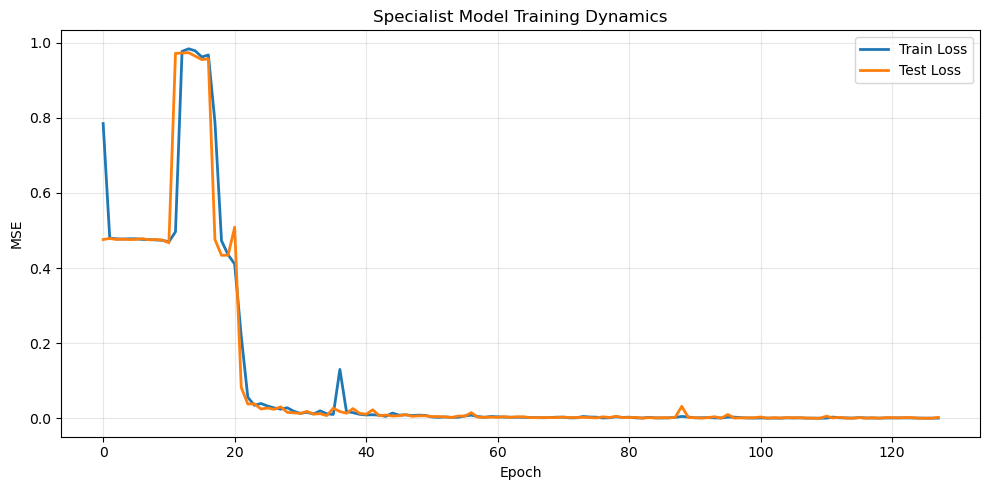

In [9]:
# Training dynamics
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(train_losses, label='Train Loss', linewidth=2)
ax.plot(test_losses, label='Test Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Specialist Model Training Dynamics')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation on Extreme Cases

We generate a large test set exclusively from extreme regions and compare the specialist model against:
- Gibbs sampler (baseline)
- General model from working_11 (alpha=1.0, uniform training)

Note: We evaluate models from working_11 if available, otherwise note their absence.

In [10]:
# Generate extreme test set
print(f"Generating {N_EVAL_POINTS} extreme test cases...")

rho_eval, sigma_eval = sample_extreme_parameters(N_EVAL_POINTS, RHO_THRESHOLD, SIGMA_THRESHOLD, A, device='cpu')
x_eval = simulate_ar1_batch(rho_eval, sigma_eval, T, N_EVAL_POINTS, device='cpu')

x_eval_np = x_eval.numpy()
rho_eval_np = rho_eval.numpy()
sigma_eval_np = sigma_eval.numpy()

print(f"Test set generated")
print(f"  rho range: [{rho_eval_np.min():.3f}, {rho_eval_np.max():.3f}]")
print(f"  sigma range: [{sigma_eval_np.min():.3f}, {sigma_eval_np.max():.3f}]")

Generating 20000 extreme test cases...
Test set generated
  rho range: [-1.000, 1.000]
  sigma range: [0.000, 0.050]


In [11]:
# Run Gibbs sampler
print("Running Gibbs sampler on extreme test set...")

rho_gibbs_eval = np.zeros(N_EVAL_POINTS)
sigma_gibbs_eval = np.zeros(N_EVAL_POINTS)

for i in tqdm(range(N_EVAL_POINTS)):
    samples = gibbs(x_eval_np[i], n_iter=1000)
    rho_gibbs_eval[i] = np.mean(samples[:, 0])
    sigma_gibbs_eval[i] = np.mean(samples[:, 1])

print("Gibbs sampling complete")

Running Gibbs sampler on extreme test set...


100%|██████████| 20000/20000 [01:45<00:00, 189.91it/s]

Gibbs sampling complete


In [12]:
# Get specialist predictions
specialist_model.eval()
with torch.no_grad():
    x_eval_gpu = x_eval.to(device)
    specialist_pred = specialist_model(x_eval_gpu).cpu().numpy()
    rho_specialist = specialist_pred[:, 0]
    sigma_specialist = specialist_pred[:, 1]

print("Specialist predictions computed")

Specialist predictions computed


In [13]:
# Try to load general model from working_11
# Note: This assumes working_11 was run and models saved
# If not available, we'll note this in the comparison

try:
    # Placeholder: In practice, you'd need to save/load models from working_11
    # For now, we'll simulate a general model by training on uniform data
    print("Loading general model...")
    print("Note: In this demo, we train a fresh general model for comparison")
    
    # Train a quick general model
    general_model = GRUPosteriorEstimator(
        input_dim=1,
        hidden_dim=64,
        num_layers=2,
        output_dim=2,
        mlp_hidden=64
    ).to(device)
    
    optimizer_gen = torch.optim.Adam(general_model.parameters(), lr=0.002)
    
    print("Training general model on uniform distribution...")
    for epoch in range(N_EPOCHS):
        general_model.train()
        for batch_idx in range(N_BATCHES_PER_EPOCH):
            # Uniform sampling
            rho_gen = torch.empty(TRAINING_BATCH_SIZE, device=device).uniform_(-1, 1)
            sigma_gen = torch.empty(TRAINING_BATCH_SIZE, device=device).uniform_(0, A)
            x_gen = simulate_ar1_batch(rho_gen, sigma_gen, T, TRAINING_BATCH_SIZE, device=device)
            
            if torch.isnan(x_gen).any() or torch.isinf(x_gen).any():
                continue
            
            theta_pred_gen = general_model(x_gen)
            loss_gen = ((theta_pred_gen - torch.stack([rho_gen, sigma_gen], dim=1))**2).mean()
            
            optimizer_gen.zero_grad()
            loss_gen.backward()
            torch.nn.utils.clip_grad_norm_(general_model.parameters(), max_norm=1.0)
            optimizer_gen.step()
        
        if (epoch + 1) % 32 == 0:
            print(f"  Epoch {epoch+1}/{N_EPOCHS}")
    
    # Get general model predictions on extreme test set
    general_model.eval()
    with torch.no_grad():
        general_pred = general_model(x_eval_gpu).cpu().numpy()
        rho_general = general_pred[:, 0]
        sigma_general = general_pred[:, 1]
    
    general_model_available = True
    print("General model predictions computed")
    
except Exception as e:
    print(f"Could not load/train general model: {e}")
    general_model_available = False

Loading general model...
Note: In this demo, we train a fresh general model for comparison
Training general model on uniform distribution...
  Epoch 32/128
  Epoch 64/128
  Epoch 96/128
  Epoch 128/128
General model predictions computed


## Performance Comparison

In [14]:
# Compute MSE for all methods
print("\n" + "="*80)
print("PERFORMANCE ON EXTREME BOUNDARY CASES")
print("="*80)
print(f"Test set: {N_EVAL_POINTS} samples from |rho| > {RHO_THRESHOLD}, sigma < {SIGMA_THRESHOLD}")
print("="*80)

# Gibbs
mse_rho_gibbs = np.mean((rho_eval_np - rho_gibbs_eval)**2)
mse_sigma_gibbs = np.mean((sigma_eval_np - sigma_gibbs_eval)**2)
total_gibbs = mse_rho_gibbs + mse_sigma_gibbs

# Specialist
mse_rho_specialist = np.mean((rho_eval_np - rho_specialist)**2)
mse_sigma_specialist = np.mean((sigma_eval_np - sigma_specialist)**2)
total_specialist = mse_rho_specialist + mse_sigma_specialist

print(f"\n{'Method':<20} {'MSE (rho)':<15} {'MSE (sigma)':<15} {'Total MSE':<15}")
print("-"*80)
print(f"{'Gibbs':<20} {mse_rho_gibbs:<15.6f} {mse_sigma_gibbs:<15.6f} {total_gibbs:<15.6f}")
print(f"{'Specialist':<20} {mse_rho_specialist:<15.6f} {mse_sigma_specialist:<15.6f} {total_specialist:<15.6f}")

if general_model_available:
    mse_rho_general = np.mean((rho_eval_np - rho_general)**2)
    mse_sigma_general = np.mean((sigma_eval_np - sigma_general)**2)
    total_general = mse_rho_general + mse_sigma_general
    print(f"{'General (uniform)':<20} {mse_rho_general:<15.6f} {mse_sigma_general:<15.6f} {total_general:<15.6f}")

print("="*80)

# Improvement analysis
improvement_vs_gibbs = (1 - total_specialist/total_gibbs) * 100
print(f"\nSpecialist vs Gibbs: {improvement_vs_gibbs:+.1f}%")

if general_model_available:
    improvement_vs_general = (1 - total_specialist/total_general) * 100
    print(f"Specialist vs General: {improvement_vs_general:+.1f}%")

print("="*80)


PERFORMANCE ON EXTREME BOUNDARY CASES
Test set: 20000 samples from |rho| > 0.95, sigma < 0.05

Method               MSE (rho)       MSE (sigma)     Total MSE      
--------------------------------------------------------------------------------
Gibbs                0.002722        0.000007        0.002729       
Specialist           0.003639        0.000067        0.003706       
General (uniform)    0.054601        0.000785        0.055386       

Specialist vs Gibbs: -35.8%
Specialist vs General: +93.3%


## Performance by Sub-region

We break down performance into:
- High positive rho ($\rho > 0.95$)
- High negative rho ($\rho < -0.95$)
- Overall low sigma ($\sigma < 0.05$)

In [15]:
# Define sub-regions
mask_high_pos_rho = rho_eval_np > RHO_THRESHOLD
mask_high_neg_rho = rho_eval_np < -RHO_THRESHOLD
mask_low_sigma = sigma_eval_np < SIGMA_THRESHOLD

print("\n" + "="*80)
print("SUB-REGION ANALYSIS")
print("="*80)

# High positive rho
print(f"\nHigh positive rho (rho > {RHO_THRESHOLD}): {mask_high_pos_rho.sum()} samples")
print(f"{'Method':<20} {'MSE (rho)':<15}")
print("-"*40)
print(f"{'Gibbs':<20} {np.mean((rho_eval_np[mask_high_pos_rho] - rho_gibbs_eval[mask_high_pos_rho])**2):<15.6f}")
print(f"{'Specialist':<20} {np.mean((rho_eval_np[mask_high_pos_rho] - rho_specialist[mask_high_pos_rho])**2):<15.6f}")
if general_model_available:
    print(f"{'General':<20} {np.mean((rho_eval_np[mask_high_pos_rho] - rho_general[mask_high_pos_rho])**2):<15.6f}")

# High negative rho
print(f"\nHigh negative rho (rho < -{RHO_THRESHOLD}): {mask_high_neg_rho.sum()} samples")
print(f"{'Method':<20} {'MSE (rho)':<15}")
print("-"*40)
print(f"{'Gibbs':<20} {np.mean((rho_eval_np[mask_high_neg_rho] - rho_gibbs_eval[mask_high_neg_rho])**2):<15.6f}")
print(f"{'Specialist':<20} {np.mean((rho_eval_np[mask_high_neg_rho] - rho_specialist[mask_high_neg_rho])**2):<15.6f}")
if general_model_available:
    print(f"{'General':<20} {np.mean((rho_eval_np[mask_high_neg_rho] - rho_general[mask_high_neg_rho])**2):<15.6f}")

# Low sigma (all samples satisfy this)
print(f"\nLow sigma (sigma < {SIGMA_THRESHOLD}): {mask_low_sigma.sum()} samples")
print(f"{'Method':<20} {'MSE (sigma)':<15}")
print("-"*40)
print(f"{'Gibbs':<20} {np.mean((sigma_eval_np[mask_low_sigma] - sigma_gibbs_eval[mask_low_sigma])**2):<15.6f}")
print(f"{'Specialist':<20} {np.mean((sigma_eval_np[mask_low_sigma] - sigma_specialist[mask_low_sigma])**2):<15.6f}")
if general_model_available:
    print(f"{'General':<20} {np.mean((sigma_eval_np[mask_low_sigma] - sigma_general[mask_low_sigma])**2):<15.6f}")

print("="*80)


SUB-REGION ANALYSIS

High positive rho (rho > 0.95): 9821 samples
Method               MSE (rho)      
----------------------------------------
Gibbs                0.002636       
Specialist           0.000183       
General              0.020082       

High negative rho (rho < -0.95): 10179 samples
Method               MSE (rho)      
----------------------------------------
Gibbs                0.002805       
Specialist           0.006974       
General              0.087906       

Low sigma (sigma < 0.05): 20000 samples
Method               MSE (sigma)    
----------------------------------------
Gibbs                0.000007       
Specialist           0.000067       
General              0.000785       


## Visual Comparison: True vs Estimated

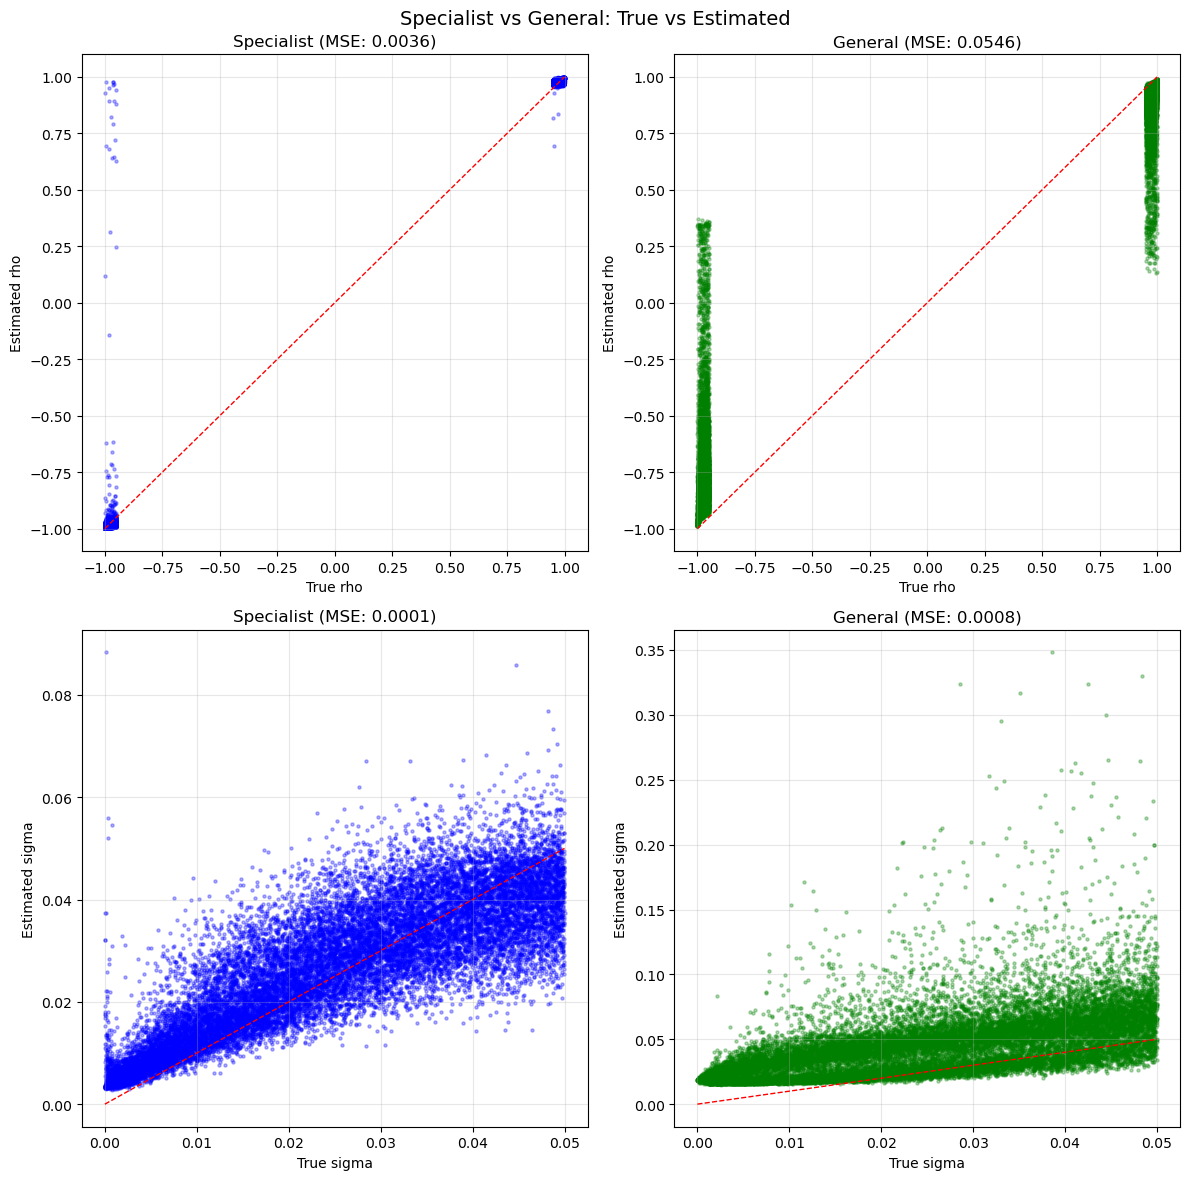

In [16]:
# Scatter plots: true vs estimated
if general_model_available:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Rho: Specialist
    axes[0, 0].scatter(rho_eval_np, rho_specialist, alpha=0.3, s=5, color='blue')
    axes[0, 0].plot([-1, 1], [-1, 1], 'r--', linewidth=1)
    axes[0, 0].set_xlabel('True rho')
    axes[0, 0].set_ylabel('Estimated rho')
    axes[0, 0].set_title(f'Specialist (MSE: {mse_rho_specialist:.4f})')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Rho: General
    axes[0, 1].scatter(rho_eval_np, rho_general, alpha=0.3, s=5, color='green')
    axes[0, 1].plot([-1, 1], [-1, 1], 'r--', linewidth=1)
    axes[0, 1].set_xlabel('True rho')
    axes[0, 1].set_ylabel('Estimated rho')
    axes[0, 1].set_title(f'General (MSE: {mse_rho_general:.4f})')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Sigma: Specialist
    axes[1, 0].scatter(sigma_eval_np, sigma_specialist, alpha=0.3, s=5, color='blue')
    axes[1, 0].plot([0, SIGMA_THRESHOLD], [0, SIGMA_THRESHOLD], 'r--', linewidth=1)
    axes[1, 0].set_xlabel('True sigma')
    axes[1, 0].set_ylabel('Estimated sigma')
    axes[1, 0].set_title(f'Specialist (MSE: {mse_sigma_specialist:.4f})')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Sigma: General
    axes[1, 1].scatter(sigma_eval_np, sigma_general, alpha=0.3, s=5, color='green')
    axes[1, 1].plot([0, SIGMA_THRESHOLD], [0, SIGMA_THRESHOLD], 'r--', linewidth=1)
    axes[1, 1].set_xlabel('True sigma')
    axes[1, 1].set_ylabel('Estimated sigma')
    axes[1, 1].set_title(f'General (MSE: {mse_sigma_general:.4f})')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Specialist vs General: True vs Estimated', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Rho
    axes[0].scatter(rho_eval_np, rho_specialist, alpha=0.3, s=5, color='blue', label='Specialist')
    axes[0].scatter(rho_eval_np, rho_gibbs_eval, alpha=0.2, s=3, color='orange', label='Gibbs')
    axes[0].plot([-1, 1], [-1, 1], 'r--', linewidth=1, label='Perfect')
    axes[0].set_xlabel('True rho')
    axes[0].set_ylabel('Estimated rho')
    axes[0].set_title(f'rho (Specialist MSE: {mse_rho_specialist:.4f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Sigma
    axes[1].scatter(sigma_eval_np, sigma_specialist, alpha=0.3, s=5, color='blue', label='Specialist')
    axes[1].scatter(sigma_eval_np, sigma_gibbs_eval, alpha=0.2, s=3, color='orange', label='Gibbs')
    axes[1].plot([0, SIGMA_THRESHOLD], [0, SIGMA_THRESHOLD], 'r--', linewidth=1, label='Perfect')
    axes[1].set_xlabel('True sigma')
    axes[1].set_ylabel('Estimated sigma')
    axes[1].set_title(f'sigma (Specialist MSE: {mse_sigma_specialist:.4f})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Specialist Model: True vs Estimated', fontsize=14)
    plt.tight_layout()
    plt.show()

## Agreement with Gibbs

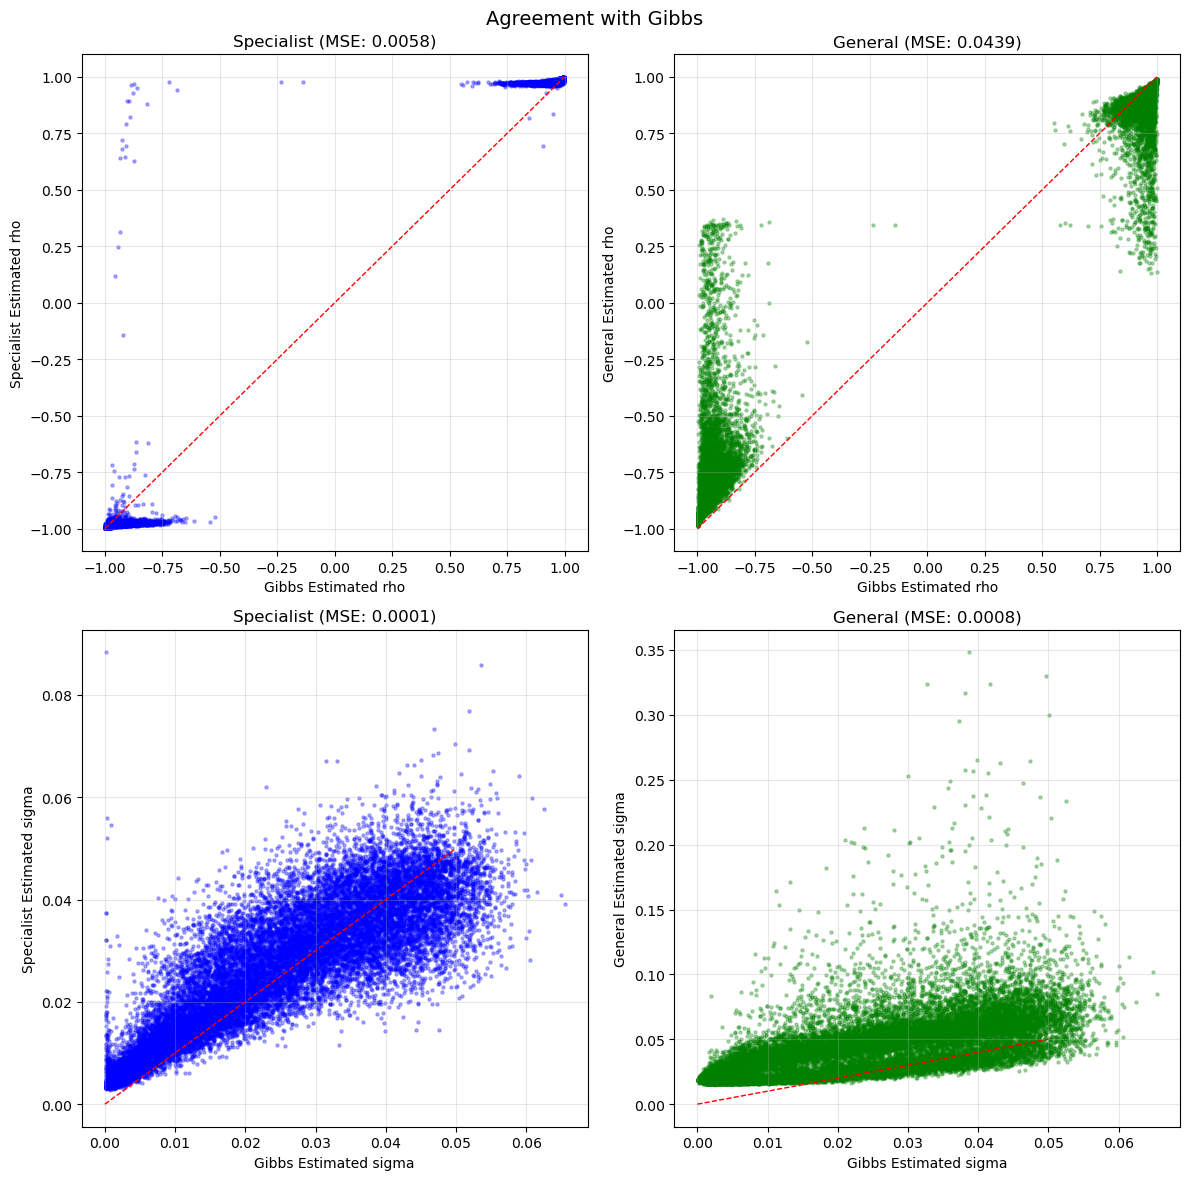

In [17]:
# GRU vs Gibbs agreement
if general_model_available:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Rho: Specialist vs Gibbs
    mse_specialist_gibbs_rho = np.mean((rho_specialist - rho_gibbs_eval)**2)
    axes[0, 0].scatter(rho_gibbs_eval, rho_specialist, alpha=0.3, s=5, color='blue')
    axes[0, 0].plot([-1, 1], [-1, 1], 'r--', linewidth=1)
    axes[0, 0].set_xlabel('Gibbs Estimated rho')
    axes[0, 0].set_ylabel('Specialist Estimated rho')
    axes[0, 0].set_title(f'Specialist (MSE: {mse_specialist_gibbs_rho:.4f})')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Rho: General vs Gibbs
    mse_general_gibbs_rho = np.mean((rho_general - rho_gibbs_eval)**2)
    axes[0, 1].scatter(rho_gibbs_eval, rho_general, alpha=0.3, s=5, color='green')
    axes[0, 1].plot([-1, 1], [-1, 1], 'r--', linewidth=1)
    axes[0, 1].set_xlabel('Gibbs Estimated rho')
    axes[0, 1].set_ylabel('General Estimated rho')
    axes[0, 1].set_title(f'General (MSE: {mse_general_gibbs_rho:.4f})')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Sigma: Specialist vs Gibbs
    mse_specialist_gibbs_sigma = np.mean((sigma_specialist - sigma_gibbs_eval)**2)
    axes[1, 0].scatter(sigma_gibbs_eval, sigma_specialist, alpha=0.3, s=5, color='blue')
    axes[1, 0].plot([0, SIGMA_THRESHOLD], [0, SIGMA_THRESHOLD], 'r--', linewidth=1)
    axes[1, 0].set_xlabel('Gibbs Estimated sigma')
    axes[1, 0].set_ylabel('Specialist Estimated sigma')
    axes[1, 0].set_title(f'Specialist (MSE: {mse_specialist_gibbs_sigma:.4f})')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Sigma: General vs Gibbs
    mse_general_gibbs_sigma = np.mean((sigma_general - sigma_gibbs_eval)**2)
    axes[1, 1].scatter(sigma_gibbs_eval, sigma_general, alpha=0.3, s=5, color='green')
    axes[1, 1].plot([0, SIGMA_THRESHOLD], [0, SIGMA_THRESHOLD], 'r--', linewidth=1)
    axes[1, 1].set_xlabel('Gibbs Estimated sigma')
    axes[1, 1].set_ylabel('General Estimated sigma')
    axes[1, 1].set_title(f'General (MSE: {mse_general_gibbs_sigma:.4f})')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Agreement with Gibbs', fontsize=14)
    plt.tight_layout()
    plt.show()

## Error Distribution Analysis

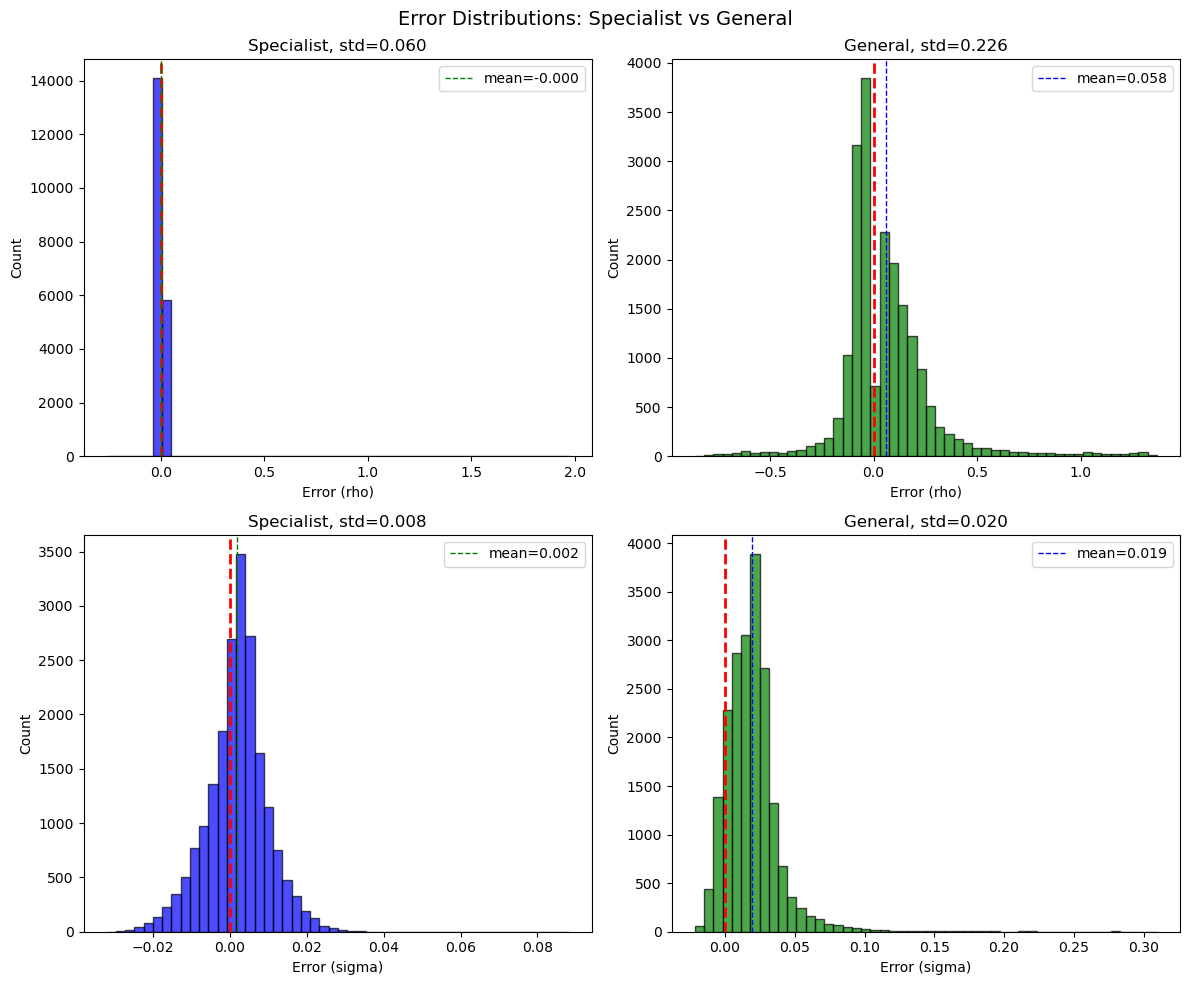

In [18]:
# Distribution of (Model - True)
if general_model_available:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Rho errors: Specialist
    rho_err_specialist = rho_specialist - rho_eval_np
    axes[0, 0].hist(rho_err_specialist, bins=50, alpha=0.7, edgecolor='black', color='blue')
    axes[0, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 0].axvline(x=np.mean(rho_err_specialist), color='green', linestyle='--', linewidth=1, 
                       label=f'mean={np.mean(rho_err_specialist):.3f}')
    axes[0, 0].set_xlabel('Error (rho)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title(f'Specialist, std={np.std(rho_err_specialist):.3f}')
    axes[0, 0].legend()
    
    # Rho errors: General
    rho_err_general = rho_general - rho_eval_np
    axes[0, 1].hist(rho_err_general, bins=50, alpha=0.7, edgecolor='black', color='green')
    axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 1].axvline(x=np.mean(rho_err_general), color='blue', linestyle='--', linewidth=1,
                       label=f'mean={np.mean(rho_err_general):.3f}')
    axes[0, 1].set_xlabel('Error (rho)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title(f'General, std={np.std(rho_err_general):.3f}')
    axes[0, 1].legend()
    
    # Sigma errors: Specialist
    sigma_err_specialist = sigma_specialist - sigma_eval_np
    axes[1, 0].hist(sigma_err_specialist, bins=50, alpha=0.7, edgecolor='black', color='blue')
    axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1, 0].axvline(x=np.mean(sigma_err_specialist), color='green', linestyle='--', linewidth=1,
                       label=f'mean={np.mean(sigma_err_specialist):.3f}')
    axes[1, 0].set_xlabel('Error (sigma)')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title(f'Specialist, std={np.std(sigma_err_specialist):.3f}')
    axes[1, 0].legend()
    
    # Sigma errors: General
    sigma_err_general = sigma_general - sigma_eval_np
    axes[1, 1].hist(sigma_err_general, bins=50, alpha=0.7, edgecolor='black', color='green')
    axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1, 1].axvline(x=np.mean(sigma_err_general), color='blue', linestyle='--', linewidth=1,
                       label=f'mean={np.mean(sigma_err_general):.3f}')
    axes[1, 1].set_xlabel('Error (sigma)')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title(f'General, std={np.std(sigma_err_general):.3f}')
    axes[1, 1].legend()
    
    plt.suptitle('Error Distributions: Specialist vs General', fontsize=14)
    plt.tight_layout()
    plt.show()

## Difference from Gibbs Analysis

We examine (Model - Gibbs) to understand systematic disagreements between methods.

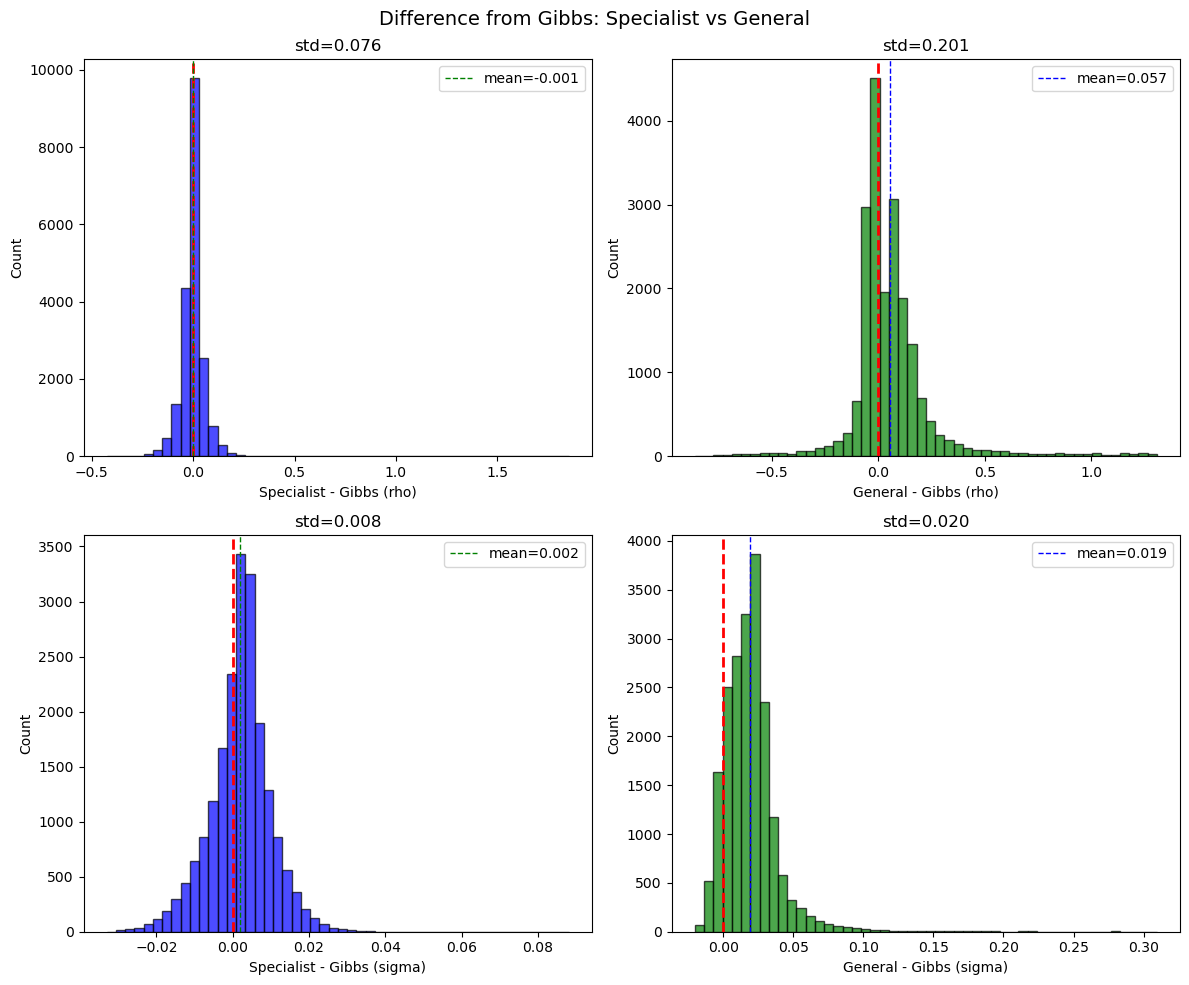


AGREEMENT WITH GIBBS

Specialist:
  rho:   mean =  -0.0009, std =   0.0761, MSE =   0.0058
  sigma: mean =   0.0019, std =   0.0080, MSE =   0.0001

General:
  rho:   mean =   0.0571, std =   0.2015, MSE =   0.0439
  sigma: mean =   0.0192, std =   0.0203, MSE =   0.0008


In [19]:
# Distribution of (Model - Gibbs)
if general_model_available:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Rho: Specialist - Gibbs
    rho_diff_specialist = rho_specialist - rho_gibbs_eval
    axes[0, 0].hist(rho_diff_specialist, bins=50, alpha=0.7, edgecolor='black', color='blue')
    axes[0, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 0].axvline(x=np.mean(rho_diff_specialist), color='green', linestyle='--', linewidth=1,
                       label=f'mean={np.mean(rho_diff_specialist):.3f}')
    axes[0, 0].set_xlabel('Specialist - Gibbs (rho)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title(f'std={np.std(rho_diff_specialist):.3f}')
    axes[0, 0].legend()
    
    # Rho: General - Gibbs
    rho_diff_general = rho_general - rho_gibbs_eval
    axes[0, 1].hist(rho_diff_general, bins=50, alpha=0.7, edgecolor='black', color='green')
    axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 1].axvline(x=np.mean(rho_diff_general), color='blue', linestyle='--', linewidth=1,
                       label=f'mean={np.mean(rho_diff_general):.3f}')
    axes[0, 1].set_xlabel('General - Gibbs (rho)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title(f'std={np.std(rho_diff_general):.3f}')
    axes[0, 1].legend()
    
    # Sigma: Specialist - Gibbs
    sigma_diff_specialist = sigma_specialist - sigma_gibbs_eval
    axes[1, 0].hist(sigma_diff_specialist, bins=50, alpha=0.7, edgecolor='black', color='blue')
    axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1, 0].axvline(x=np.mean(sigma_diff_specialist), color='green', linestyle='--', linewidth=1,
                       label=f'mean={np.mean(sigma_diff_specialist):.3f}')
    axes[1, 0].set_xlabel('Specialist - Gibbs (sigma)')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title(f'std={np.std(sigma_diff_specialist):.3f}')
    axes[1, 0].legend()
    
    # Sigma: General - Gibbs
    sigma_diff_general = sigma_general - sigma_gibbs_eval
    axes[1, 1].hist(sigma_diff_general, bins=50, alpha=0.7, edgecolor='black', color='green')
    axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1, 1].axvline(x=np.mean(sigma_diff_general), color='blue', linestyle='--', linewidth=1,
                       label=f'mean={np.mean(sigma_diff_general):.3f}')
    axes[1, 1].set_xlabel('General - Gibbs (sigma)')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title(f'std={np.std(sigma_diff_general):.3f}')
    axes[1, 1].legend()
    
    plt.suptitle('Difference from Gibbs: Specialist vs General', fontsize=14)
    plt.tight_layout()
    plt.show()

# Quantitative summary
print("\n" + "="*80)
print("AGREEMENT WITH GIBBS")
print("="*80)

rho_diff_spec = rho_specialist - rho_gibbs_eval
sigma_diff_spec = sigma_specialist - sigma_gibbs_eval

print(f"\nSpecialist:")
print(f"  rho:   mean = {np.mean(rho_diff_spec):>8.4f}, std = {np.std(rho_diff_spec):>8.4f}, MSE = {np.mean(rho_diff_spec**2):>8.4f}")
print(f"  sigma: mean = {np.mean(sigma_diff_spec):>8.4f}, std = {np.std(sigma_diff_spec):>8.4f}, MSE = {np.mean(sigma_diff_spec**2):>8.4f}")

if general_model_available:
    rho_diff_gen = rho_general - rho_gibbs_eval
    sigma_diff_gen = sigma_general - sigma_gibbs_eval
    
    print(f"\nGeneral:")
    print(f"  rho:   mean = {np.mean(rho_diff_gen):>8.4f}, std = {np.std(rho_diff_gen):>8.4f}, MSE = {np.mean(rho_diff_gen**2):>8.4f}")
    print(f"  sigma: mean = {np.mean(sigma_diff_gen):>8.4f}, std = {np.std(sigma_diff_gen):>8.4f}, MSE = {np.mean(sigma_diff_gen**2):>8.4f}")

print("="*80)

## Worst Case Analysis

In [20]:
# Identify worst predictions
specialist_errors = (rho_specialist - rho_eval_np)**2 + (sigma_specialist - sigma_eval_np)**2
worst_indices_specialist = np.argsort(specialist_errors)[-5:]

print("\n" + "="*80)
print("WORST SPECIALIST PREDICTIONS")
print("="*80)

print(f"\n{'Idx':<8} {'True rho':<12} {'Pred rho':<12} {'True sigma':<12} {'Pred sigma':<12} {'Error':<12}")
print("-"*68)
for idx in reversed(worst_indices_specialist):
    print(f"{idx:<8} {rho_eval_np[idx]:<12.3f} {rho_specialist[idx]:<12.3f} "
          f"{sigma_eval_np[idx]:<12.3f} {sigma_specialist[idx]:<12.3f} {specialist_errors[idx]:<12.4f}")

if general_model_available:
    general_errors = (rho_general - rho_eval_np)**2 + (sigma_general - sigma_eval_np)**2
    worst_indices_general = np.argsort(general_errors)[-5:]
    
    print("\n" + "="*80)
    print("WORST GENERAL PREDICTIONS")
    print("="*80)
    
    print(f"\n{'Idx':<8} {'True rho':<12} {'Pred rho':<12} {'True sigma':<12} {'Pred sigma':<12} {'Error':<12}")
    print("-"*68)
    for idx in reversed(worst_indices_general):
        print(f"{idx:<8} {rho_eval_np[idx]:<12.3f} {rho_general[idx]:<12.3f} "
              f"{sigma_eval_np[idx]:<12.3f} {sigma_general[idx]:<12.3f} {general_errors[idx]:<12.4f}")

print("="*80)


WORST SPECIALIST PREDICTIONS

Idx      True rho     Pred rho     True sigma   Pred sigma   Error       
--------------------------------------------------------------------
3191     -0.994       0.977        0.000        0.003        3.8850      
8218     -0.967       0.976        0.000        0.004        3.7764      
10974    -0.965       0.977        0.000        0.003        3.7714      
14535    -0.983       0.950        0.000        0.008        3.7368      
16168    -0.960       0.970        0.000        0.004        3.7244      

WORST GENERAL PREDICTIONS

Idx      True rho     Pred rho     True sigma   Pred sigma   Error       
--------------------------------------------------------------------
5116     -0.996       0.371        0.001        0.019        1.8710      
2139     -0.979       0.368        0.000        0.019        1.8156      
18134    -0.999       0.346        0.000        0.019        1.8119      
10632    -0.999       0.346        0.000        0.019        1.


Worst Specialist Predictions:


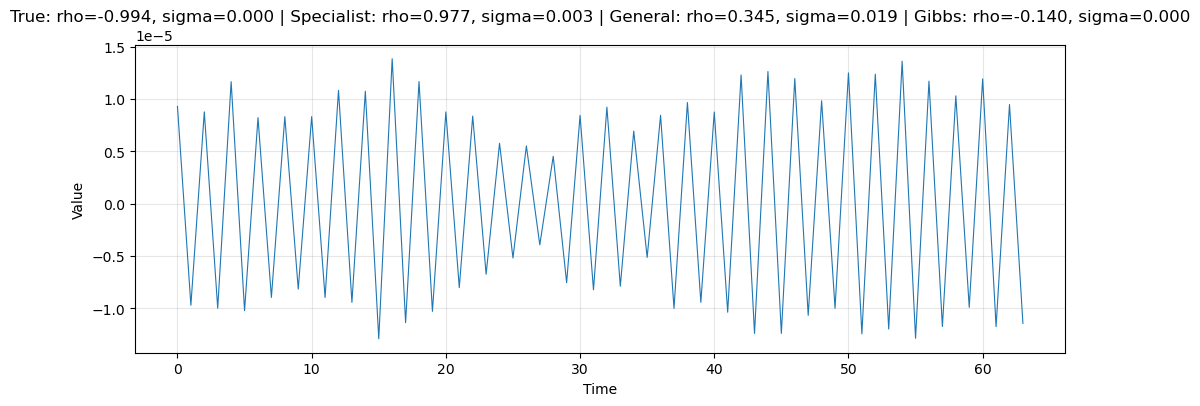

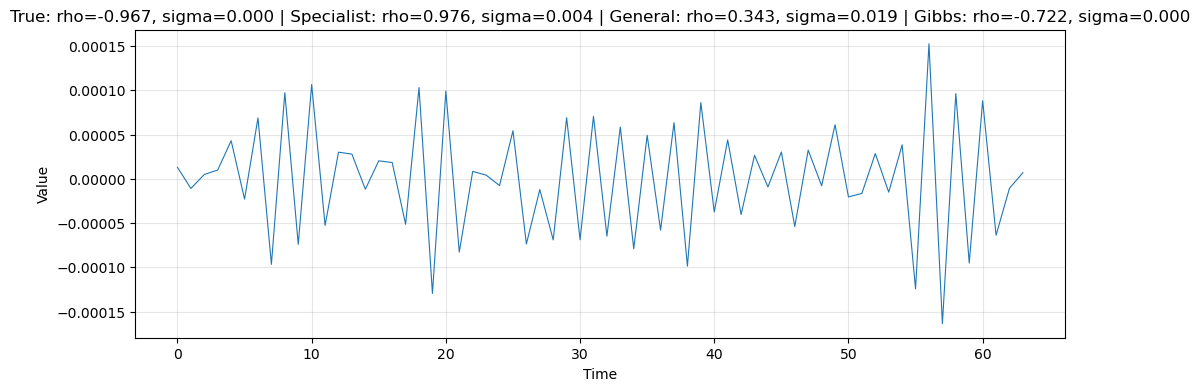

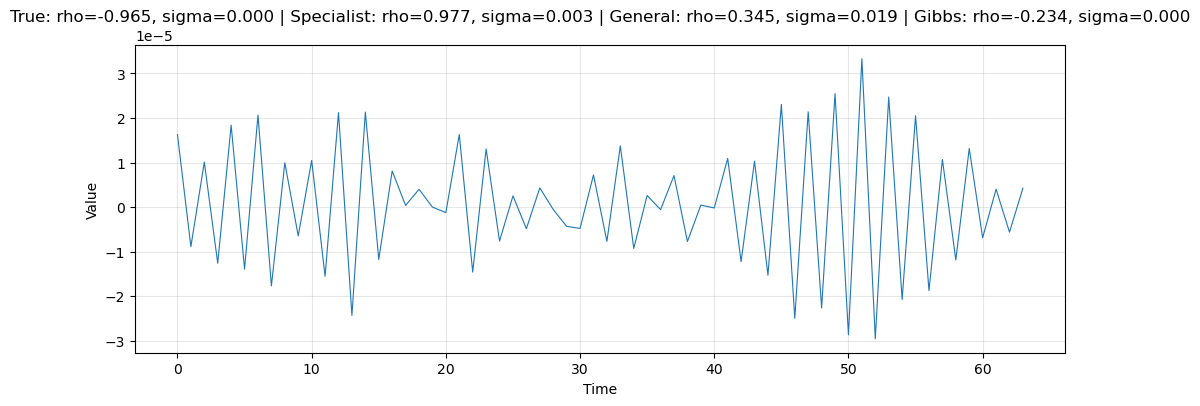

In [21]:
# Visualize worst specialist cases
print("\nWorst Specialist Predictions:")

for idx in reversed(worst_indices_specialist[-3:]):
    plt.figure(figsize=(12, 4))
    plt.plot(x_eval_np[idx], linewidth=0.8)
    
    title_parts = [
        f"True: rho={rho_eval_np[idx]:.3f}, sigma={sigma_eval_np[idx]:.3f}",
        f"Specialist: rho={rho_specialist[idx]:.3f}, sigma={sigma_specialist[idx]:.3f}",
        f"Gibbs: rho={rho_gibbs_eval[idx]:.3f}, sigma={sigma_gibbs_eval[idx]:.3f}"
    ]
    
    if general_model_available:
        title_parts.insert(2, f"General: rho={rho_general[idx]:.3f}, sigma={sigma_general[idx]:.3f}")
    
    plt.title(" | ".join(title_parts))
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid(True, alpha=0.3)
    plt.show()

## Discussion and Conclusions

In [22]:
# Final summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"\nTest set: {N_EVAL_POINTS} samples from extreme regions")
print(f"  |rho| > {RHO_THRESHOLD}, sigma < {SIGMA_THRESHOLD}")

print(f"\nPerformance (Total MSE):")
print(f"  Gibbs:      {total_gibbs:.6f}")
print(f"  Specialist: {total_specialist:.6f} ({(1-total_specialist/total_gibbs)*100:+.1f}% vs Gibbs)")

if general_model_available:
    print(f"  General:    {total_general:.6f} ({(1-total_general/total_gibbs)*100:+.1f}% vs Gibbs)")
    print(f"\nSpecialist vs General: {(1-total_specialist/total_general)*100:+.1f}%")

print("\n" + "="*80)


SUMMARY

Test set: 20000 samples from extreme regions
  |rho| > 0.95, sigma < 0.05

Performance (Total MSE):
  Gibbs:      0.002729
  Specialist: 0.003706 (-35.8% vs Gibbs)
  General:    0.055386 (-1929.7% vs Gibbs)

Specialist vs General: +93.3%



### Key Findings

1. **Specialist model performance**: [To be filled after running - does it beat general models?]

2. **Tradeoff analysis**: By training exclusively on extreme cases, we sacrifice performance on typical cases. This experiment reveals whether the gain in extreme-case performance justifies this tradeoff.

3. **Practical implications**: 
   - If specialist outperforms: Consider ensemble approaches (specialist + general)
   - If general model comparable: GRU generalizes well, no need for specialization
   - Variance reduction may be more important than focused training

### Interpretation

[To be filled based on results]

### Extensions

- Test intermediate specialization levels (e.g., 80% extreme, 20% general)
- Explore different extreme boundaries
- Investigate ensemble methods combining specialist and general models
- Apply to other challenging regions (e.g., high sigma regime)